Histogram creation

Research question: Do survivors and non-survivors of the Titanic differ in their average age?

Data source: The dataset used in this analysis comes from Kaggle: 
Titanic Dataset:
https://www.kaggle.com/datasets/brendan45774/test-file?resource=download 
This dataset includes information about Titanic passangers such as age, sex, passenger class, fare, number of family members abroad, and survival status. The data was originally compiled from historical passenger records, ship manifests, and survivor list from the 1912 Titanic disaster. For the purpose of this statistic analysis, the Age and Survived variables were used (missing values were removed).

In [1]:
# Imported Libraries
import pandas as pd               # data object library
import matplotlib.pyplot as plt   # plotting library
import numpy as np
from scipy import stats

In [ ]:
df = pd.read_csv("data\titanic.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [31]:
# Start by reading the Titanic dataset data from the csv file which should be located
# in the SAME directory as the ipynb file

#Clean: remove rows with missing Age
df_clean = df.dropna(subset = ["Age"])

# Create two group for comparison

sample1 = df_clean[df_clean["Survived"] == 1]["Age"] #Survivors
sample2 = df_clean[df_clean["Survived"] == 0]["Age"] #Non-survivors

# extract just the math scores but for completed and non-completed
sample1_text = "Survivors (Age)"
sample2_text = "Non-survivors (Age)"

print(sample1)
print(sample2)

print("Number of Observations in Sample 1: " + str(len(sample1)))
print("Number of Observations in Sample 2: " + str(len(sample2)))

1      47.0
4      22.0
6      30.0
8      18.0
12     23.0
       ... 
402    22.0
409     3.0
411    37.0
412    28.0
414    39.0
Name: Age, Length: 127, dtype: float64
0      34.5
2      62.0
3      27.0
5      14.0
7      26.0
       ... 
404    43.0
405    20.0
406    23.0
407    50.0
415    38.5
Name: Age, Length: 205, dtype: float64
Number of Observations in Sample 1: 127
Number of Observations in Sample 2: 205


In [52]:
# brute force gathering of bins
# create the bins manually

def create_histogram(data, xaxis, yaxis, title):
    bins = list(range(0, 90, 5))  # (0–90],... thus the values are the right side of the bin 
    freq = [0] * len(bins)        # represents the frequency for each bin -- list multiplication

    # loop through the data 
    for i in range(len(data)):
        # gather the data point
        data_point = data.iloc[i]  
        
        # loop through the intervals and see where it belongs
        for j in range(len(bins)):
            if data_point <= bins[j]:
                freq[j] = freq[j] + 1
                break

    # plot our data
    plt.bar(bins, freq, color='blue', width=6)
    plt.xlabel(xaxis)
    plt.ylabel(yaxis)
    plt.title(title)
    plt.show()


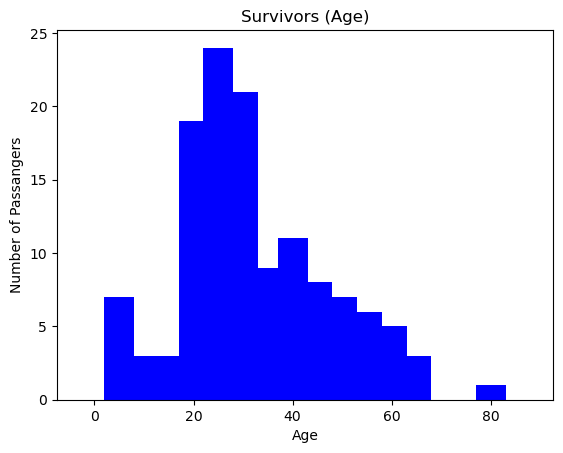

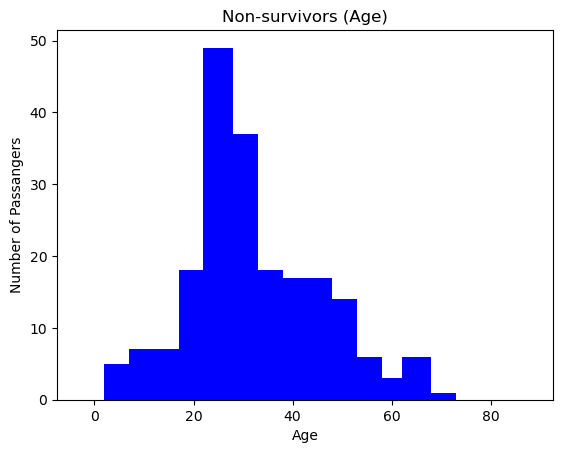

In [53]:
# histogram for completed and non-complete
create_histogram(sample1, 'Age', 'Number of Passangers', sample1_text)
create_histogram(sample2, 'Age', 'Number of Passangers', sample2_text)

In [33]:
def summary_stats(data):
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_dev = np.std(data)
    range_val = np.max(data) - np.min(data)
    percentile_75 = np.percentile(data, 75)
    percentile_25 = np.percentile(data, 25)
    IQR = percentile_75 - percentile_25

    print(f"Mean: {mean_val}")
    print(f"Median: {median_val}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Range: {range_val}")
    print(f"Inter-quartile Range: {IQR}")


In [54]:
print("~~~~~~~~~~~~~~~~~~~~")
print("Survivors")
print("~~~~~~~~~~~~~~~~~~~~")
summary_stats(sample1)

print("~~~~~~~~~~~~~~~~~~~~")
print("Non-Survivors")
print("~~~~~~~~~~~~~~~~~~~~")
summary_stats(sample2)


~~~~~~~~~~~~~~~~~~~~
Survivors
~~~~~~~~~~~~~~~~~~~~
Mean: 30.27236220472441
Median: 27.0
Standard Deviation: 15.367750333913566
Range: 75.83
Inter-quartile Range: 18.0
~~~~~~~~~~~~~~~~~~~~
Non-Survivors
~~~~~~~~~~~~~~~~~~~~
Mean: 30.27273170731707
Median: 27.0
Standard Deviation: 13.356831059514423
Range: 66.67
Inter-quartile Range: 18.0


In [55]:
t_statistic, p_value = stats.ttest_ind(sample1, sample2, equal_var=True)
alpha = 0.05

print("~~~~~~~~~~~~~~~~~")
print("Two Sample T-test")
print("~~~~~~~~~~~~~~~~~")
print("H0: Mean age of survivors = mean age of non-survivors")
print("HA: Means are different")

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print("Reject H0: There IS a significant difference in age between survivors and non-survivors.")
else:
    print("Fail to reject H0: There is NO significant difference in age.")


~~~~~~~~~~~~~~~~~
Two Sample T-test
~~~~~~~~~~~~~~~~~
H0: Mean age of survivors = mean age of non-survivors
HA: Means are different
T-statistic: -0.000230386457754343
P-value: 0.9998163174099579
Fail to reject H0: There is NO significant difference in age.


Conclusion

Statistical analysis shows whether the age of the surviving Titanic passengers differs significantly from those who did not survive (based on the p-value according to the t-test). Test produces a very small t-test  (-0.00023) and very large p-value (0.9998) where  p-value is much greater that the significance value of 0.05. 

Summary statistics and histograms show the age distribution in each group. In the historical context, young passengers, especially children, had a better chance of survival due to evacuation procedures such as “women and children first.”

In this context, this suggests that age was not the main determinant of survival on the Titanic. Other factors, such as the passenger's gender and class, probably played a much more important role in survival outcomes.